# Информация о данных
- Это набор данных о клиентах американского банка, который позволяет получить информацию о том, уйдет ли конкретный клиент из банка или нет
## Информация о столбцах/признаках
В наборе данных представлена информация о клиентах банка:
- *RowNumber* - номер строки в наборе данных
- *CustomerId* - идентификатор клиента
- *Surname* - фамилия клиента
- *CreditScore* - кредитный рейтинг клиента
- *Geography* - местонахождение клиента
- *Gender* - пол клиента
- *Age* - возраст клиента
- *Tenure* - сколько лет клиент пользуется услугами банка
- *Balance* - средний баланс клиента в долларах
- *NumOfProducts* - количество банковских продуктов (услуг), которыми пользуется клиент (например, сберегательный счет, кредитная карта)
- *HasCrCard* - есть ли кредитная карта
- *IsActiveMember* - булевая переменная, является ли клиент активным пользователем услуг банка
- *EstimatedSalary* - предполагаемая заработная плата
- *Exited* - булевая переменная, пользуется ли клиент услугами (отток) - целевая переменная

# EDA

Импортируем нужные библиотеки и зададим настройку для отображения всех столбцов

Рассмотрим набор данных. Выделим основную информацию

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
pd.set_option('display.max_columns', None)

In [3]:
bank_churn = pd.read_csv(r'E:\bankChurnProject\bank-churn\main\data\raw\Churn_Modelling.csv')
bank_churn

,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,1,15634602,Hargrave,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,2,15647311,Hill,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,3,15619304,Onio,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,4,15701354,Boni,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,5,15737888,Mitchell,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9995,9996,15606229,Obijiaku,771,France,Male,39,5,0.00,2,1,0,96270.64,0
9996,9997,15569892,Johnstone,516,France,Male,35,10,57369.61,1,1,1,101699.77,0
9997,9998,15584532,Liu,709,France,Female,36,7,0.00,1,0,1,42085.58,1
9998,9999,15682355,Sabbatini,772,Germany,Male,42,3,75075.31,2,1,0,92888.52,1


In [34]:
df = bank_churn.copy()

In [4]:
bank_churn.info()

<class 'pandas.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 14 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   RowNumber        10000 non-null  int64  
 1   CustomerId       10000 non-null  int64  
 2   Surname          10000 non-null  str    
 3   CreditScore      10000 non-null  int64  
 4   Geography        10000 non-null  str    
 5   Gender           10000 non-null  str    
 6   Age              10000 non-null  int64  
 7   Tenure           10000 non-null  int64  
 8   Balance          10000 non-null  float64
 9   NumOfProducts    10000 non-null  int64  
 10  HasCrCard        10000 non-null  int64  
 11  IsActiveMember   10000 non-null  int64  
 12  EstimatedSalary  10000 non-null  float64
 13  Exited           10000 non-null  int64  
dtypes: float64(2), int64(9), str(3)
memory usage: 1.1 MB


Проверка на пропуски: пропусков в атрибутах нет

In [5]:
bank_churn.isna().sum()

RowNumber          0
CustomerId         0
Surname            0
CreditScore        0
Geography          0
Gender             0
Age                0
Tenure             0
Balance            0
NumOfProducts      0
HasCrCard          0
IsActiveMember     0
EstimatedSalary    0
Exited             0
dtype: int64

In [6]:
bank_churn.columns

Index(['RowNumber', 'CustomerId', 'Surname', 'CreditScore', 'Geography',
       'Gender', 'Age', 'Tenure', 'Balance', 'NumOfProducts', 'HasCrCard',
       'IsActiveMember', 'EstimatedSalary', 'Exited'],
      dtype='str')

Выделим целочисленные столбцы (без учета идентификационных столбцов)

In [7]:
num_cols = bank_churn[['CreditScore',
       'Gender', 'Age', 'Tenure', 'Balance', 'NumOfProducts', 'HasCrCard',
       'IsActiveMember', 'EstimatedSalary', 'Exited']].select_dtypes(exclude='object')
num_cols.shape

(10000, 9)

In [8]:
num_cols.describe()

,CreditScore,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
count,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.00000,10000.000000,10000.000000,10000.000000
mean,650.528800,38.921800,5.012800,76485.889288,1.530200,0.70550,0.515100,100090.239881,0.203700
std,96.653299,10.487806,2.892174,62397.405202,0.581654,0.45584,0.499797,57510.492818,0.402769
min,350.000000,18.000000,0.000000,0.000000,1.000000,0.00000,0.000000,11.580000,0.000000
25%,584.000000,32.000000,3.000000,0.000000,1.000000,0.00000,0.000000,51002.110000,0.000000
50%,652.000000,37.000000,5.000000,97198.540000,1.000000,1.00000,1.000000,100193.915000,0.000000
75%,718.000000,44.000000,7.000000,127644.240000,2.000000,1.00000,1.000000,149388.247500,0.000000
max,850.000000,92.000000,10.000000,250898.090000,4.000000,1.00000,1.000000,199992.480000,1.000000


In [9]:
# Избавимся от столбца с номером строки, столбца страны, имени
bank_churn_subset = bank_churn[['CustomerId', 'CreditScore',
       'Gender', 'Age', 'Tenure', 'Balance', 'NumOfProducts', 'HasCrCard',
       'IsActiveMember', 'EstimatedSalary', 'Exited']]
bank_churn_subset

,CustomerId,CreditScore,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,15634602,619,Female,42,2,0.00,1,1,1,101348.88,1
1,15647311,608,Female,41,1,83807.86,1,0,1,112542.58,0
2,15619304,502,Female,42,8,159660.80,3,1,0,113931.57,1
3,15701354,699,Female,39,1,0.00,2,0,0,93826.63,0
4,15737888,850,Female,43,2,125510.82,1,1,1,79084.10,0
...,...,...,...,...,...,...,...,...,...,...,...
9995,15606229,771,Male,39,5,0.00,2,1,0,96270.64,0
9996,15569892,516,Male,35,10,57369.61,1,1,1,101699.77,0
9997,15584532,709,Female,36,7,0.00,1,0,1,42085.58,1
9998,15682355,772,Male,42,3,75075.31,2,1,0,92888.52,1


array([[<Axes: title={'center': 'CreditScore'}>,
        <Axes: title={'center': 'Age'}>,
        <Axes: title={'center': 'Tenure'}>],
       [<Axes: title={'center': 'Balance'}>,
        <Axes: title={'center': 'NumOfProducts'}>,
        <Axes: title={'center': 'HasCrCard'}>],
       [<Axes: title={'center': 'IsActiveMember'}>,
        <Axes: title={'center': 'EstimatedSalary'}>,
        <Axes: title={'center': 'Exited'}>]], dtype=object)

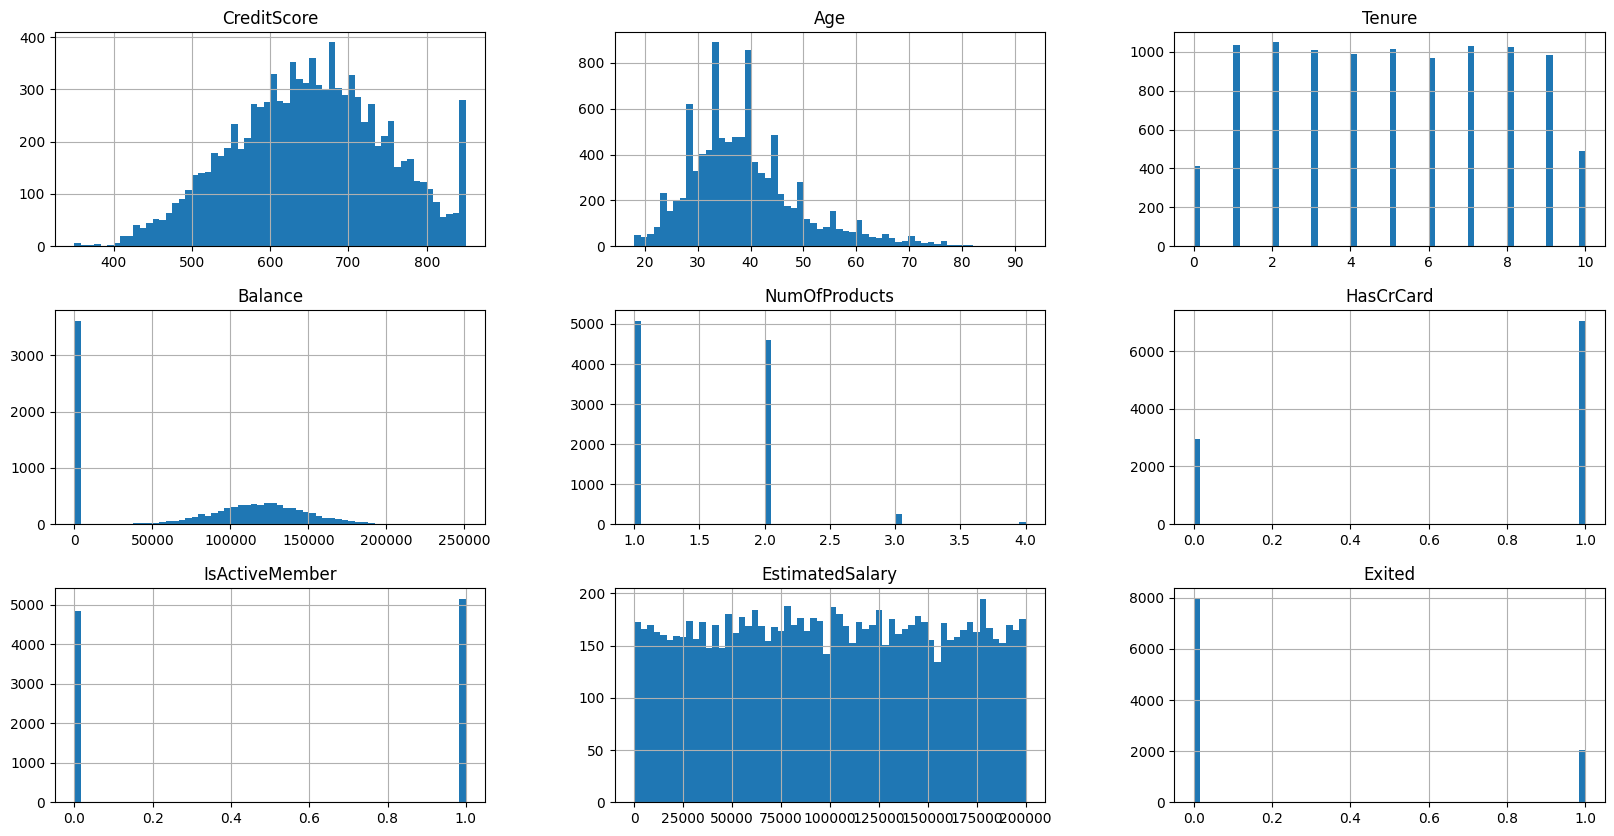

In [10]:
# построим гистограммы всех числовых признаков
num_cols.hist(bins=60, figsize=(20,10))

Выделим категориальные столбцы - только пол

In [11]:
cat_cols = bank_churn_subset[['Gender']]
cat_cols

,Gender
0,Female
1,Female
2,Female
3,Female
4,Female
...,...
9995,Male
9996,Male
9997,Female
9998,Male


In [12]:
cat_cols.describe()

,Gender
count,10000
unique,2
top,Male
freq,5457


In [13]:
country = bank_churn['Gender'].value_counts()
country

Gender
Male      5457
Female    4543
Name: count, dtype: int64

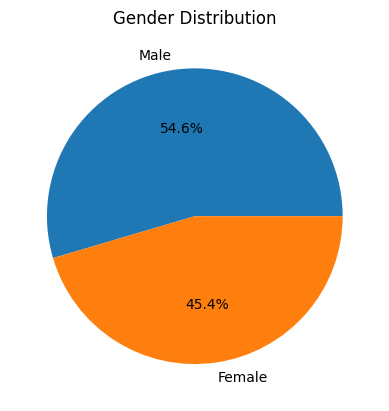

In [14]:
plt.pie(country, labels=country.index, autopct='%1.1f%%')
plt.title('Gender Distribution')
plt.show()

Большинство клиентов банка - Мужчины (54.6%)

<Axes: >

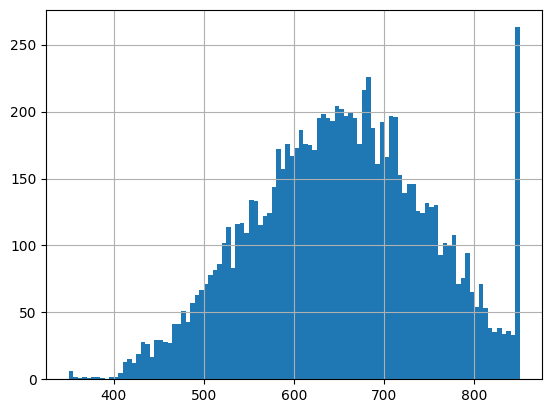

In [15]:
credit_score = bank_churn['CreditScore']
credit_score.hist(bins=100)

Заметим большое количество людей с кредитным рейтингом ровно 850. Возможно ошибка в данных или синтетически созданные данные

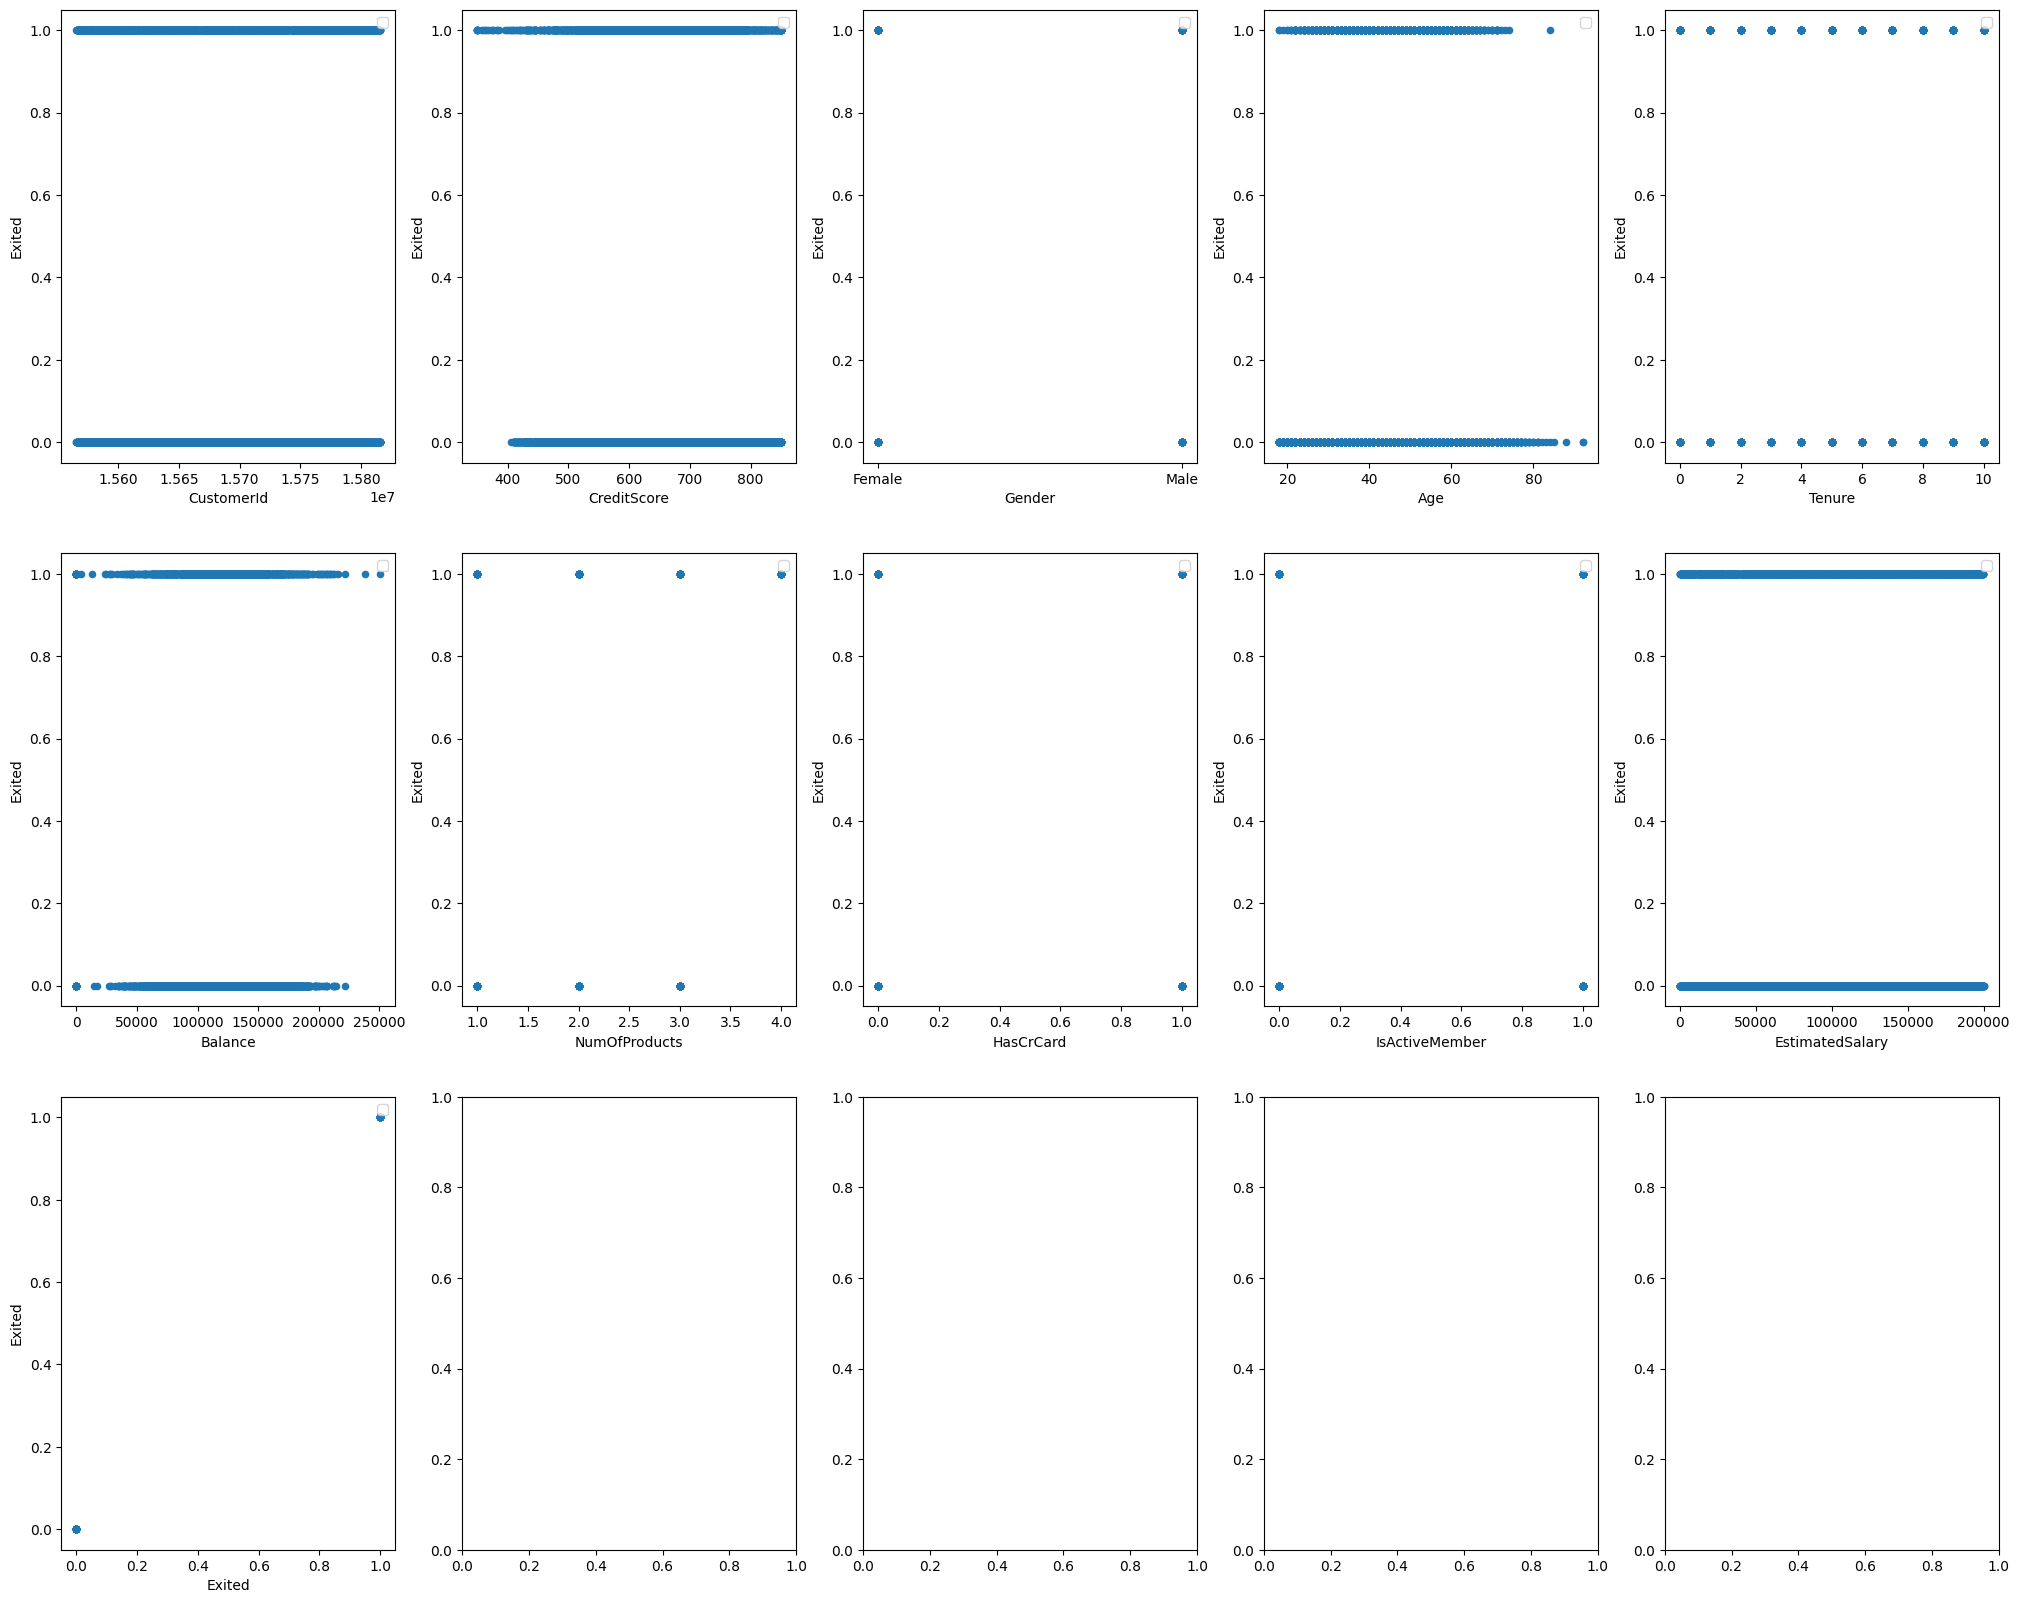

In [16]:
fig, axes = plt.subplots(nrows=3, ncols=5, figsize=(25, 20))
for idx, feature in enumerate(bank_churn_subset.columns):
    bank_churn_subset.plot(feature, "Exited", subplots=True, kind="scatter", ax=axes[idx // 5, idx % 5])

GENDER ANALYSIS
Churn Rate by Gender:
Female: 25.07% (25.1%)
Male: 16.46% (16.5%)

Detailed Statistics:
        Total Customers  Churn Rate  Churned Customers  Churn Rate %
Gender                                                              
Female             4543    0.250715               1139     25.071539
Male               5457    0.164559                898     16.455928


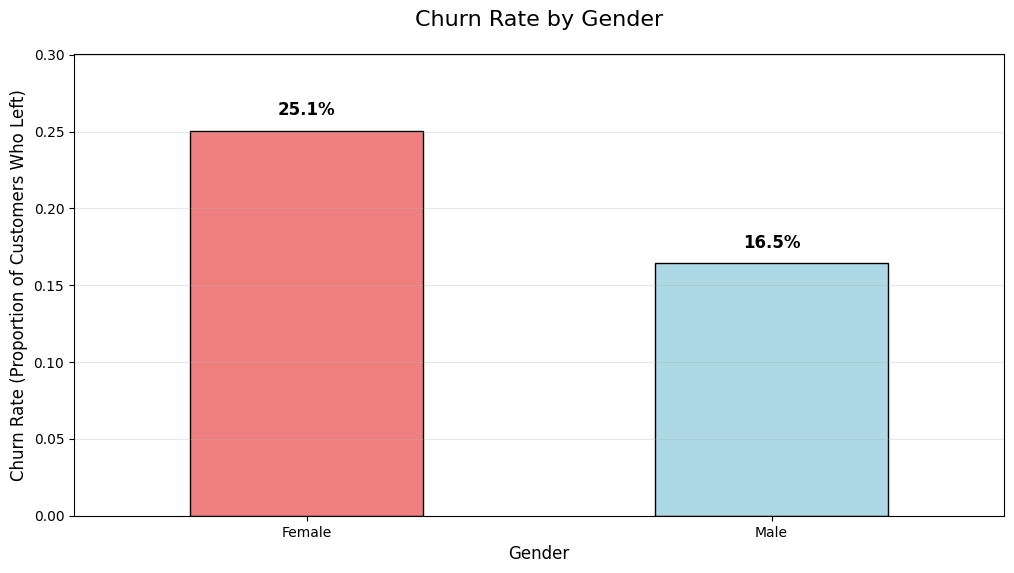

In [17]:
import numpy as np

# График 1: Уровень оттока по полу
plt.figure(figsize=(12, 6))

# Вычисляем уровень оттока по полу
churn_by_gender = bank_churn_subset.groupby('Gender')['Exited'].mean()

# Строим bar plot
ax = churn_by_gender.plot(kind='bar', color=['lightcoral', 'lightblue'], edgecolor='black')

# Добавляем значения на столбцы
for i, v in enumerate(churn_by_gender):
    ax.text(i, v + 0.01, f'{v:.1%}', ha='center', fontsize=12, fontweight='bold')

plt.title('Churn Rate by Gender', fontsize=16, pad=20)
plt.xlabel('Gender', fontsize=12)
plt.ylabel('Churn Rate (Proportion of Customers Who Left)', fontsize=12)
plt.xticks(rotation=0)
plt.ylim(0, max(churn_by_gender) + 0.05)
plt.grid(axis='y', alpha=0.3)

print("=" * 50)
print("GENDER ANALYSIS")
print("=" * 50)
print("Churn Rate by Gender:")
for gender, rate in churn_by_gender.items():
    print(f"{gender}: {rate:.2%} ({rate*100:.1f}%)")

# Детальная статистика
gender_stats = bank_churn_subset.groupby('Gender')['Exited'].agg(['count', 'mean', 'sum'])
gender_stats.columns = ['Total Customers', 'Churn Rate', 'Churned Customers']
gender_stats['Churn Rate %'] = gender_stats['Churn Rate'] * 100
print("\nDetailed Statistics:")
print(gender_stats)

plt.show()

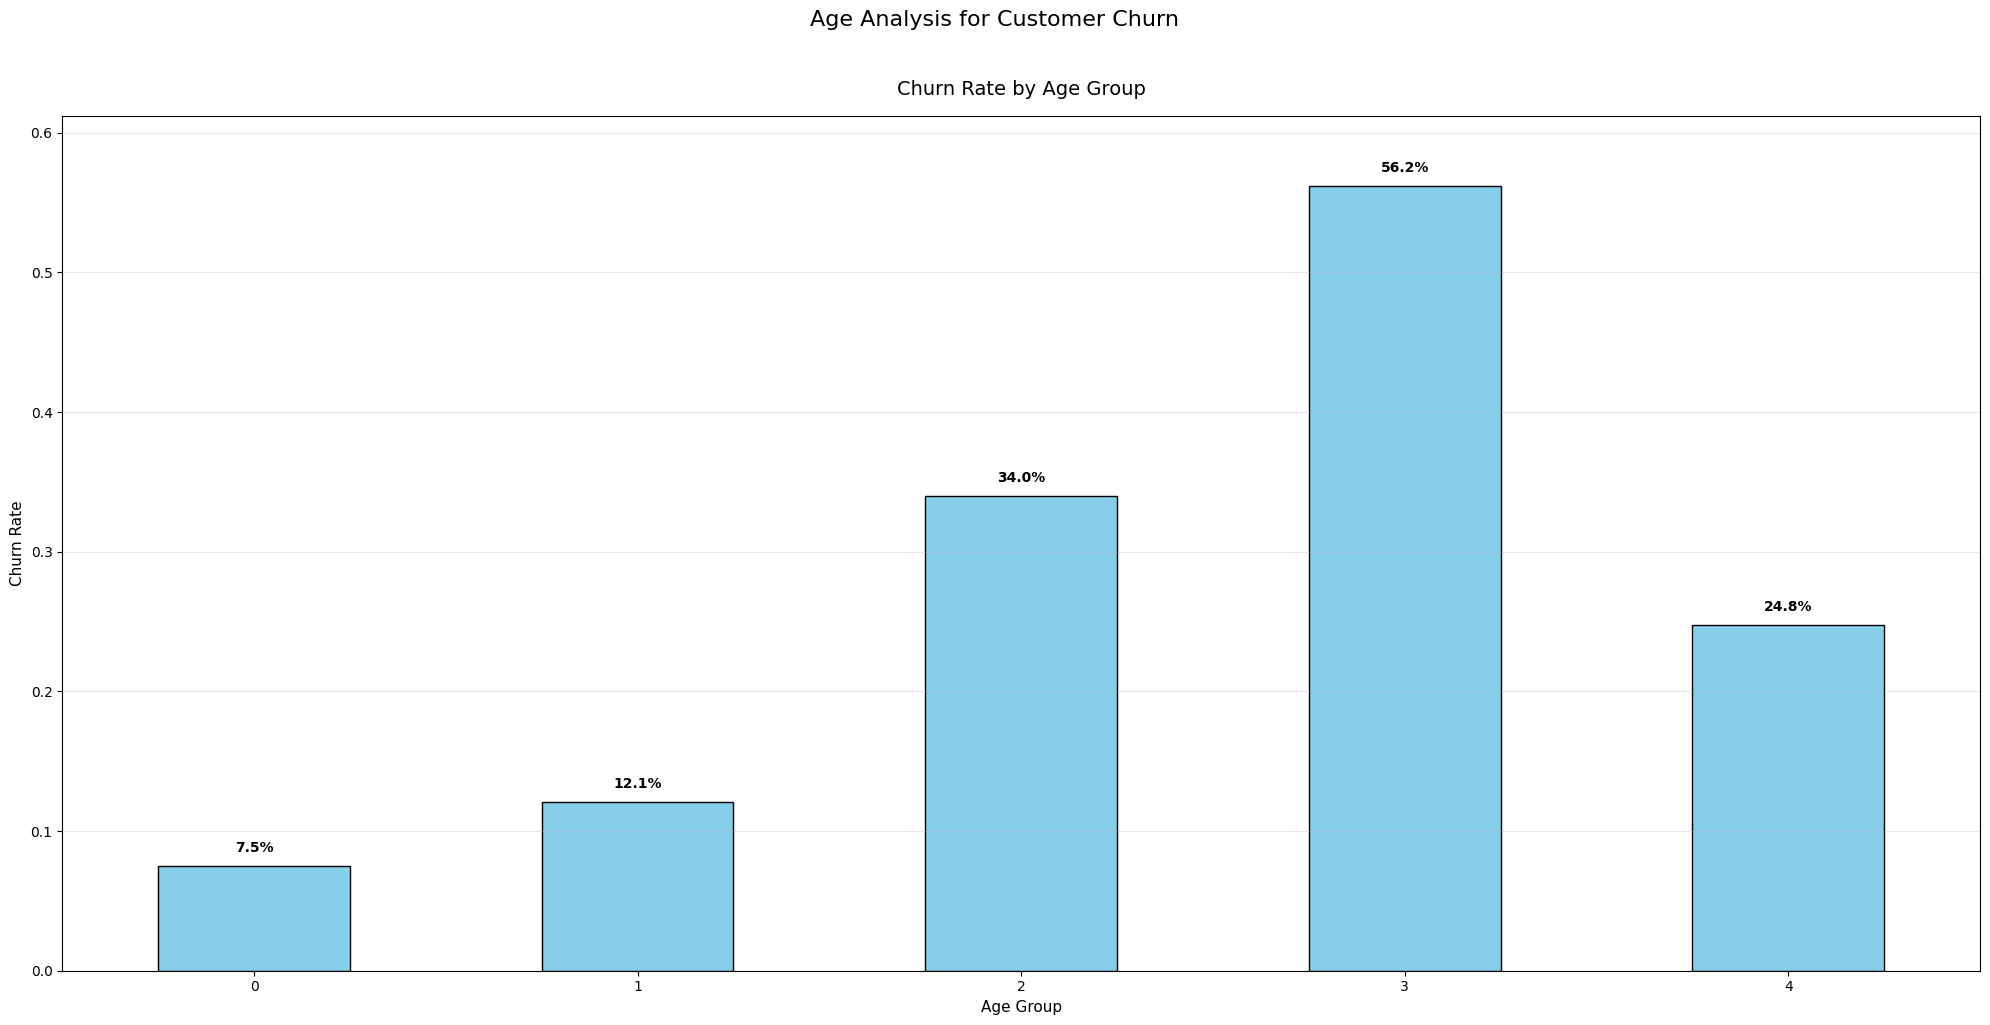


Churn Rate by Age Group:
0: 7.50% (146/1946 customers)
1: 12.09% (538/4451 customers)
2: 33.97% (788/2320 customers)
3: 56.21% (448/797 customers)
4: 24.78% (115/464 customers)


In [25]:
# Создаем figure с несколькими подграфиками для возраста
fig, axes = plt.subplots(1,1, figsize=(20,10))

# Уровень оттока по возрастным группам
bank_churn_subset['Age_Group'] = pd.cut(bank_churn['Age'], 
                                  bins=[18, 30, 40, 50, 60, 100],
                                  labels=[0, 1, 2, 3, 4])  # 0=18-30, 4=60+

churn_by_age_group = bank_churn_subset.groupby('Age_Group')['Exited'].mean()

ax1 = churn_by_age_group.plot(kind='bar', color='skyblue', edgecolor='black', ax=axes)
for i, v in enumerate(churn_by_age_group):
    ax1.text(i, v + 0.01, f'{v:.1%}', ha='center', fontsize=10, fontweight='bold')
ax1.set_title('Churn Rate by Age Group', fontsize=14, pad=15)
ax1.set_xlabel('Age Group', fontsize=11)
ax1.set_ylabel('Churn Rate', fontsize=11)
ax1.set_ylim(0, max(churn_by_age_group) + 0.05)
ax1.grid(axis='y', alpha=0.3)
ax1.tick_params(axis='x', rotation=0)

plt.suptitle('Age Analysis for Customer Churn', fontsize=16, y=1.02)
plt.tight_layout()
plt.show()

print()
print("Churn Rate by Age Group:")
for group in churn_by_age_group.index:
    total = len(bank_churn_subset[bank_churn_subset['Age_Group'] == group])
    churned = len(bank_churn_subset[(bank_churn_subset['Age_Group'] == group) & 
                                    (bank_churn_subset['Exited'] == 1)])
    rate = churn_by_age_group[group]
    print(f"{group}: {rate:.2%} ({churned}/{total} customers)")

<Figure size 1200x600 with 0 Axes>

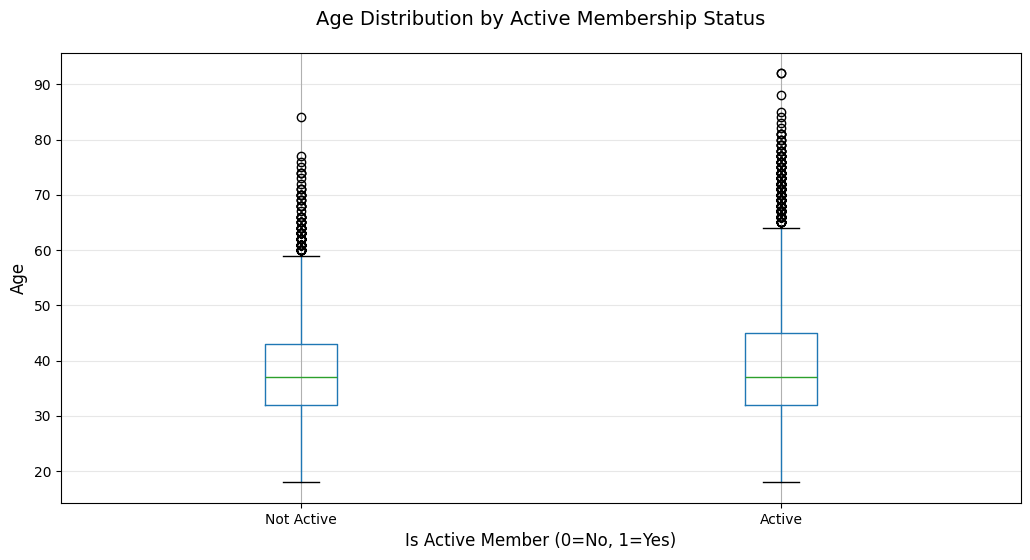

In [26]:
plt.figure(figsize=(12, 6))

# Box plot: распределение возраста для активных и неактивных клиентов
bank_churn_subset.boxplot(column='Age', by='IsActiveMember', figsize=(12, 6))
plt.title('Age Distribution by Active Membership Status', fontsize=14, pad=20)
plt.suptitle('')  # Убираем автоматический заголовок
plt.xlabel('Is Active Member (0=No, 1=Yes)', fontsize=12)
plt.ylabel('Age', fontsize=12)
plt.xticks([1, 2], ['Not Active', 'Active'], rotation=0)
plt.grid(axis='y', alpha=0.3)
plt.show()

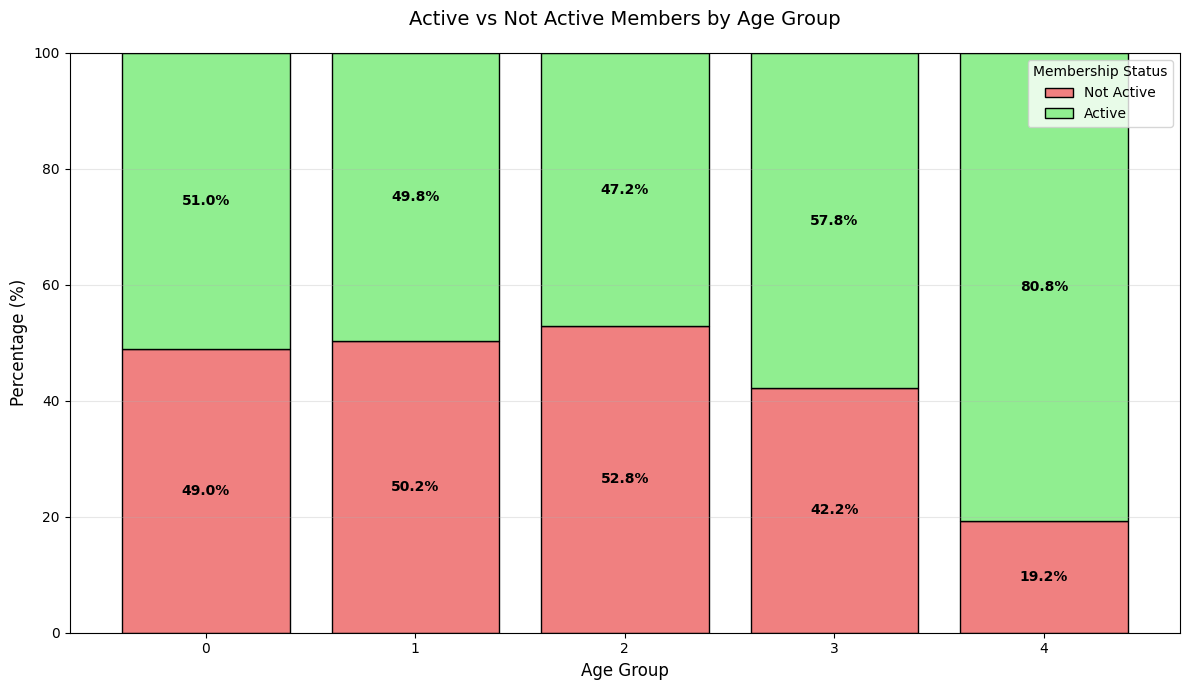

In [27]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

# Создаем сводную таблицу
age_activity = pd.crosstab(bank_churn_subset['Age_Group'], 
                           bank_churn_subset['IsActiveMember'],
                           normalize='index') * 100

# График
fig, ax = plt.subplots(figsize=(12, 7))

age_activity.plot(kind='bar', stacked=True, ax=ax, 
                  color=['lightcoral', 'lightgreen'], 
                  edgecolor='black', width=0.8)

# Добавляем проценты на столбцы
for i, (idx, row) in enumerate(age_activity.iterrows()):
    # Для неактивных (нижняя часть)
    ax.text(i, row[0]/2, f'{row[0]:.1f}%', 
            ha='center', va='center', fontsize=10, fontweight='bold')
    # Для активных (верхняя часть)
    ax.text(i, row[0] + row[1]/2, f'{row[1]:.1f}%', 
            ha='center', va='center', fontsize=10, fontweight='bold')

ax.set_title('Active vs Not Active Members by Age Group', fontsize=14, pad=20)
ax.set_xlabel('Age Group', fontsize=12)
ax.set_ylabel('Percentage (%)', fontsize=12)
ax.legend(['Not Active', 'Active'], title='Membership Status', fontsize=10)
ax.tick_params(axis='x', rotation=0)
ax.set_ylim(0, 100)
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

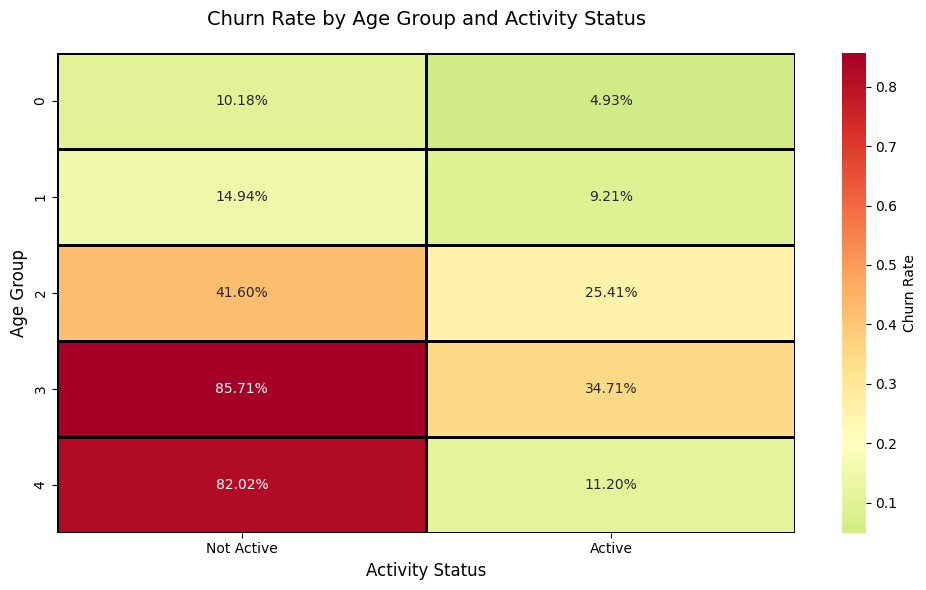

In [28]:


# Создаем сводную таблицу для heatmap
heatmap_data = bank_churn_subset.pivot_table(
    values='Exited',
    index='Age_Group',
    columns='IsActiveMember',
    aggfunc='mean'
)

heatmap_data.columns = ['Not Active', 'Active']

plt.figure(figsize=(10, 6))
import seaborn as sns
sns.heatmap(heatmap_data, annot=True, fmt='.2%', cmap='RdYlGn_r', 
            center=0.2, linewidths=1, linecolor='black',
            cbar_kws={'label': 'Churn Rate'})
plt.title('Churn Rate by Age Group and Activity Status', fontsize=14, pad=20)
plt.xlabel('Activity Status', fontsize=12)
plt.ylabel('Age Group', fontsize=12)
plt.tight_layout()
plt.show()

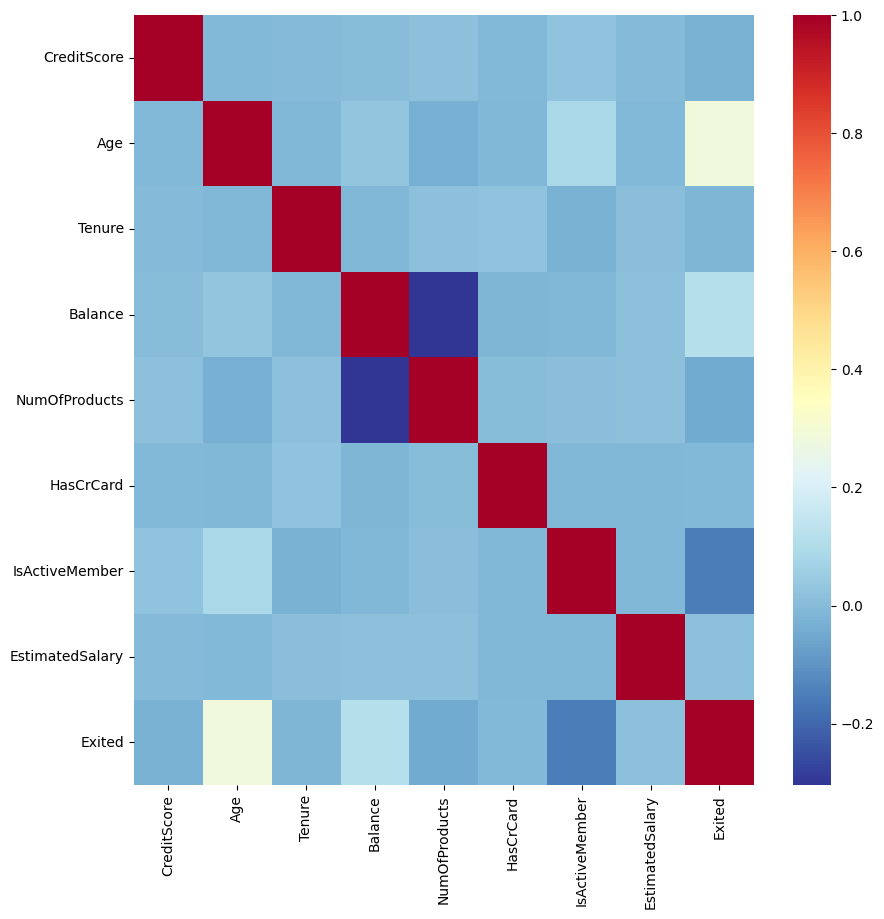

In [29]:
plt.figure(figsize=(10,10))
sns.heatmap(num_cols.corr(), cmap="RdYlBu_r");

По тепловой карте корреляции можем сделать вывод:
- Есть небольшая положительная корреляция *AGE* и *EXITED*
- Есть значительная отрицательная корреляция *BALANCE* и *NUMOFPRODUCTS*
- Есть небольшая положительная корреляция *AGE* и *ISACTIVEMEMBER*
- Есть небольшая положительная корреляция *BALANCE* и *EXITED*
- Есть небольшая отрицательная корреляция *ISACTIVEMEMBER* и *EXITED*

In [31]:
# Отношение стажа к возрасту (лояльность)
bank_churn_subset['Tenure_Ratio'] = bank_churn_subset['Tenure'] / bank_churn_subset['Age']

# Баланс на продукт (средний баланс на услугу)
bank_churn_subset['Balance_Per_Product'] = bank_churn_subset['Balance'] / (bank_churn_subset['NumOfProducts'] + 1)

# Активность с учетом возраста
bank_churn_subset['Active_Senior'] = ((bank_churn_subset['Age'] > 50) & (bank_churn_subset['IsActiveMember'] == 1)).astype(int)

# Есть ли баланс (0 или >0)
bank_churn_subset['Has_Balance'] = (bank_churn_subset['Balance'] > 0).astype(int)

In [53]:
bank_churn_subset

,CustomerId,CreditScore,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited,Age_Group,Tenure_Ratio,Balance_Per_Product,Active_Senior,Has_Balance
0,15634602,619,Female,42,2,0.00,1,1,1,101348.88,1,2,0.047619,0.000000,0,0
1,15647311,608,Female,41,1,83807.86,1,0,1,112542.58,0,2,0.024390,41903.930000,0,1
2,15619304,502,Female,42,8,159660.80,3,1,0,113931.57,1,2,0.190476,39915.200000,0,1
3,15701354,699,Female,39,1,0.00,2,0,0,93826.63,0,1,0.025641,0.000000,0,0
4,15737888,850,Female,43,2,125510.82,1,1,1,79084.10,0,2,0.046512,62755.410000,0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9995,15606229,771,Male,39,5,0.00,2,1,0,96270.64,0,1,0.128205,0.000000,0,0
9996,15569892,516,Male,35,10,57369.61,1,1,1,101699.77,0,1,0.285714,28684.805000,0,1
9997,15584532,709,Female,36,7,0.00,1,0,1,42085.58,1,1,0.194444,0.000000,0,0
9998,15682355,772,Male,42,3,75075.31,2,1,0,92888.52,1,2,0.071429,25025.103333,0,1


CREDIT SCORE ANALYSIS

              mean  median         std
Exited                                
0       651.853196   653.0   95.653837
1       645.351497   646.0  100.321503


C:\Users\Русмина\AppData\Local\Temp\ipykernel_6632\851691015.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Exited', y='CreditScore', data=df, palette='Set2')


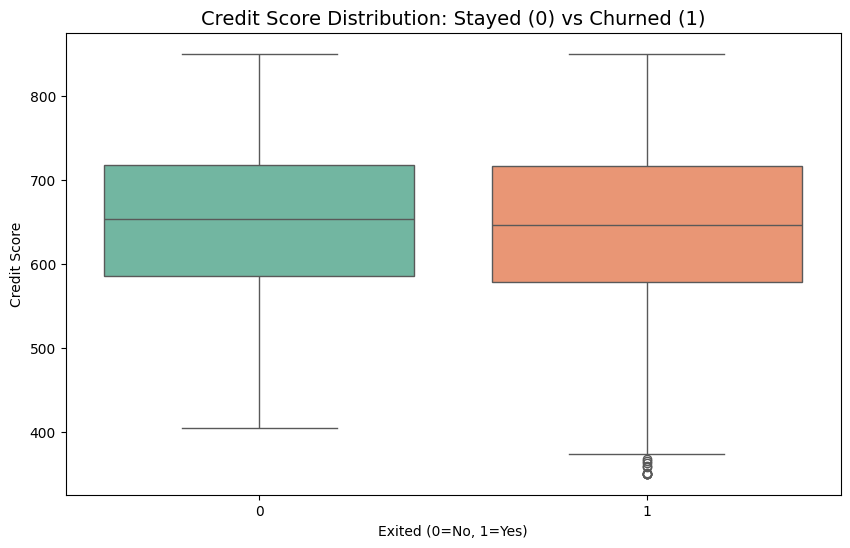

T-test p-value: 0.0067
Вывод: Есть статистически значимая разница


In [36]:
# Группировка по оттоку
credit_by_exit = df.groupby('Exited')['CreditScore'].agg(['mean', 'median', 'std'])
print(credit_by_exit)

# Визуализация
plt.figure(figsize=(10,6))
sns.boxplot(x='Exited', y='CreditScore', data=df, palette='Set2')
plt.title('Credit Score Distribution: Stayed (0) vs Churned (1)', fontsize=14)
plt.xlabel('Exited (0=No, 1=Yes)')
plt.ylabel('Credit Score')
plt.show()

# Статистический тест
from scipy import stats
churned_credit = df[df['Exited']==1]['CreditScore']
stayed_credit = df[df['Exited']==0]['CreditScore']
t_stat, p_value = stats.ttest_ind(churned_credit, stayed_credit)
print(f"T-test p-value: {p_value:.4f}")
print(f"Вывод: {'Есть статистически значимая разница' if p_value < 0.05 else 'Нет значимой разницы'}")

TENURE ANALYSIS

            mean  median
Exited                  
0       5.033279     5.0
1       4.932744     5.0


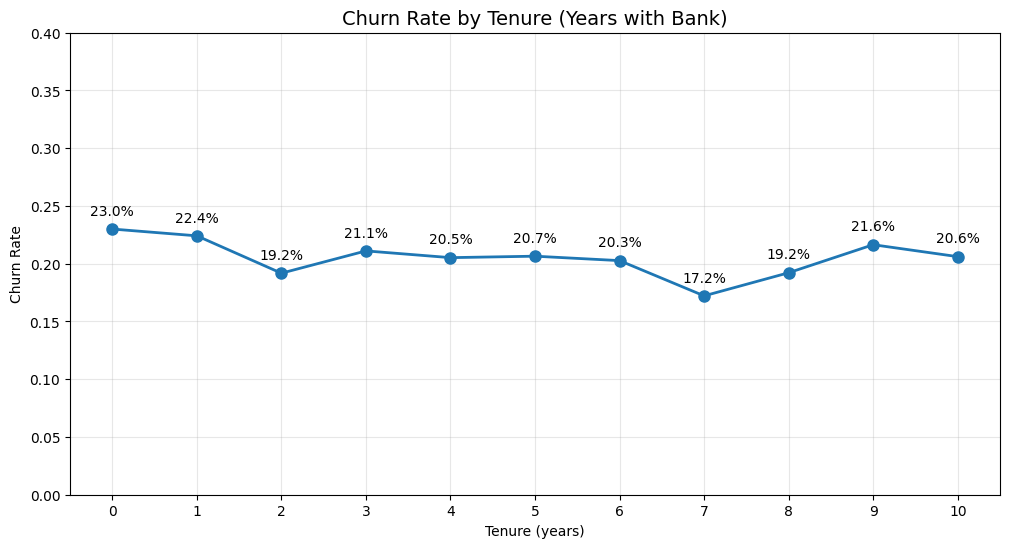

Средний стаж ушедших: 4.93 лет
Средний стаж оставшихся: 5.03 лет


In [46]:
# Статистика
tenure_stats = df.groupby('Exited')['Tenure'].agg(['mean', 'median'])
print(tenure_stats)

# Отток по стажу
tenure_churn = df.groupby('Tenure')['Exited'].mean()

plt.figure(figsize=(12,6))
plt.plot(tenure_churn.index, tenure_churn.values, marker='o', linewidth=2, markersize=8)
plt.title('Churn Rate by Tenure (Years with Bank)', fontsize=14)
plt.xlabel('Tenure (years)')
plt.ylabel('Churn Rate')
plt.xticks(range(0, 11))
plt.ylim(0, 0.4)
plt.grid(True, alpha=0.3)
for x, y in tenure_churn.items():
    plt.annotate(f'{y:.1%}', (x, y), textcoords="offset points", xytext=(0,10), ha='center')
plt.show()

# Вывод
print(f"Средний стаж ушедших: {tenure_stats.loc[1, 'mean']:.2f} лет")
print(f"Средний стаж оставшихся: {tenure_stats.loc[0, 'mean']:.2f} лет")

BALANCE ANALYSIS

                mean     median           std
Exited                                       
0       72745.296779   92072.68  62848.040701
1       91108.539337  109349.29  58360.794816

Клиенты с нулевым балансом: 3617 (36.2%)
Из них ушли: 500 (13.8%)


C:\Users\Русмина\AppData\Local\Temp\ipykernel_6632\1670179576.py:22: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Exited', y='Balance', data=df, ax=axes[1], palette='Set2')


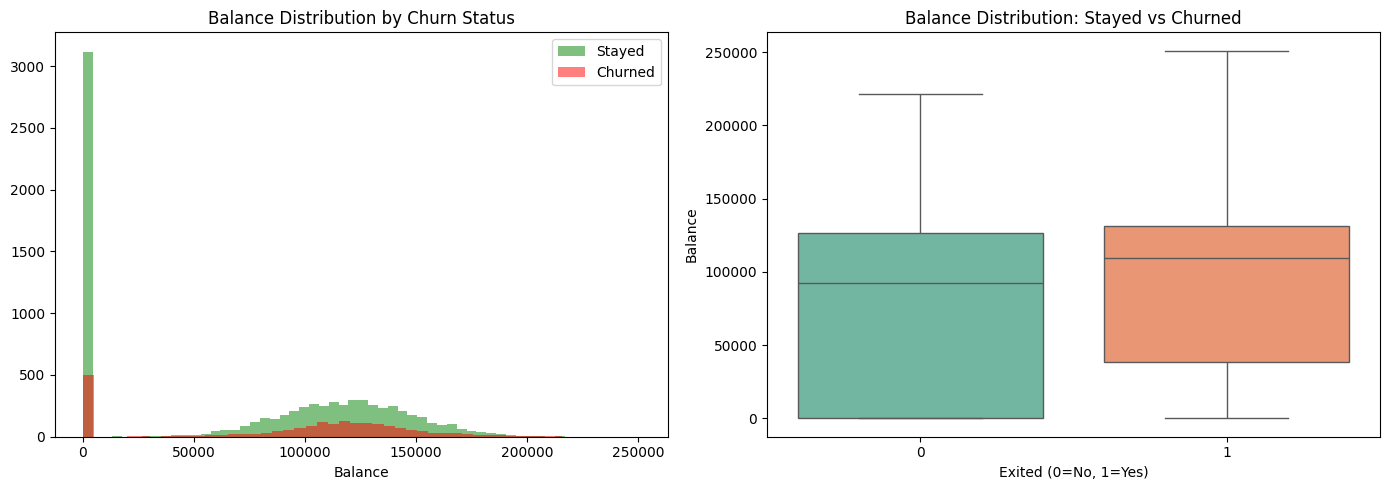

In [47]:
# Статистика
balance_stats = df.groupby('Exited')['Balance'].agg(['mean', 'median', 'std'])
print(balance_stats)

# Процент клиентов с нулевым балансом
zero_balance = df['Balance'] == 0
zero_by_exit = df[zero_balance].groupby('Exited').size()
print(f"\nКлиенты с нулевым балансом: {zero_by_exit.sum()} ({zero_by_exit.sum()/len(df):.1%})")
print(f"Из них ушли: {zero_by_exit.get(1, 0)} ({zero_by_exit.get(1, 0)/zero_by_exit.sum():.1%})")

# Визуализация
fig, axes = plt.subplots(1, 2, figsize=(14,5))

# Гистограмма
axes[0].hist(df[df['Exited']==0]['Balance'], bins=50, alpha=0.5, label='Stayed', color='green')
axes[0].hist(df[df['Exited']==1]['Balance'], bins=50, alpha=0.5, label='Churned', color='red')
axes[0].set_title('Balance Distribution by Churn Status')
axes[0].set_xlabel('Balance')
axes[0].legend()

# Box plot
sns.boxplot(x='Exited', y='Balance', data=df, ax=axes[1], palette='Set2')
axes[1].set_title('Balance Distribution: Stayed vs Churned')
axes[1].set_xlabel('Exited (0=No, 1=Yes)')

plt.tight_layout()
plt.show()

NUMBER OF PRODUCTS ANALYSIS

               Total  Churn Rate
NumOfProducts                   
1               5084    0.277144
2               4590    0.075817
3                266    0.827068
4                 60    1.000000


C:\Users\Русмина\AppData\Local\Temp\ipykernel_6632\1916793702.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='NumOfProducts', y='Exited', data=df, palette='viridis', errorbar=None)


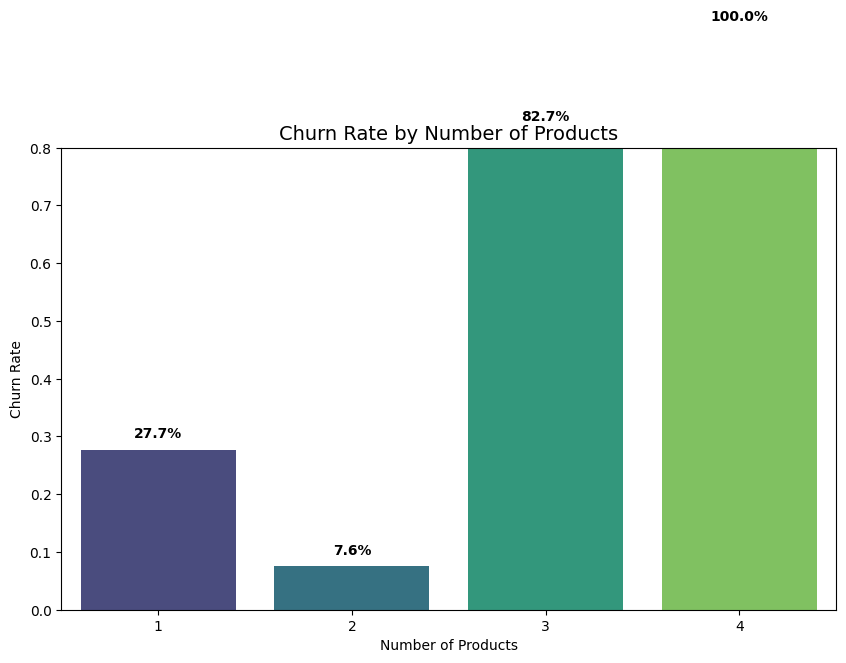


Клиенты с 4 продуктами: 60
Из них ушли: 60 (100.0%)


In [48]:
# Отток по количеству продуктов
product_stats = df.groupby('NumOfProducts')['Exited'].agg(['count', 'mean'])
product_stats.columns = ['Total', 'Churn Rate']
print(product_stats)

# Визуализация
plt.figure(figsize=(10,6))
sns.barplot(x='NumOfProducts', y='Exited', data=df, palette='viridis', errorbar=None)
plt.title('Churn Rate by Number of Products', fontsize=14)
plt.xlabel('Number of Products')
plt.ylabel('Churn Rate')
for i, v in enumerate(product_stats['Churn Rate']):
    plt.text(i, v + 0.02, f'{v:.1%}', ha='center', fontweight='bold')
plt.ylim(0, 0.8)
plt.show()

# Аномалия: 4 продукта
products_4 = df[df['NumOfProducts'] == 4]
print(f"\nКлиенты с 4 продуктами: {len(products_4)}")
print(f"Из них ушли: {products_4['Exited'].sum()} ({products_4['Exited'].mean():.1%})")

CREDIT CARD ANALYSIS

                 Total  Churn Rate
No Credit Card    2945    0.208149
Has Credit Card   7055    0.201843


C:\Users\Русмина\AppData\Local\Temp\ipykernel_6632\3960873991.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='HasCrCard', y='Exited', data=df, palette='pastel', errorbar=None)


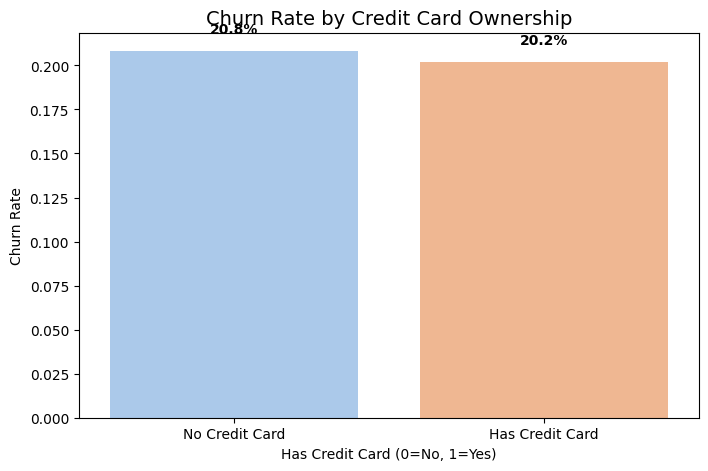

Chi-square p-value: 0.4924


In [50]:
# Отток по наличию кредитки
card_stats = df.groupby('HasCrCard')['Exited'].agg(['count', 'mean'])
card_stats.index = ['No Credit Card', 'Has Credit Card']
card_stats.columns = ['Total', 'Churn Rate']
print(card_stats)

# Визуализация
plt.figure(figsize=(8,5))
sns.barplot(x='HasCrCard', y='Exited', data=df, palette='pastel', errorbar=None)
plt.title('Churn Rate by Credit Card Ownership', fontsize=14)
plt.xlabel('Has Credit Card (0=No, 1=Yes)')
plt.ylabel('Churn Rate')
plt.xticks([0, 1], ['No Credit Card', 'Has Credit Card'])
for i, v in enumerate(card_stats['Churn Rate']):
    plt.text(i, v + 0.01, f'{v:.1%}', ha='center', fontweight='bold')
plt.show()

# Chi-square тест
contingency = pd.crosstab(df['HasCrCard'], df['Exited'])
chi2, p, dof, expected = chi2_contingency(contingency)
print(f"Chi-square p-value: {p:.4f}")

ACTIVE MEMBERSHIP ANALYSIS

            Total  Churn Rate
Not Active   4849    0.268509
Active       5151    0.142691


C:\Users\Русмина\AppData\Local\Temp\ipykernel_6632\3893994304.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='IsActiveMember', y='Exited', data=df, palette='coolwarm', errorbar=None)


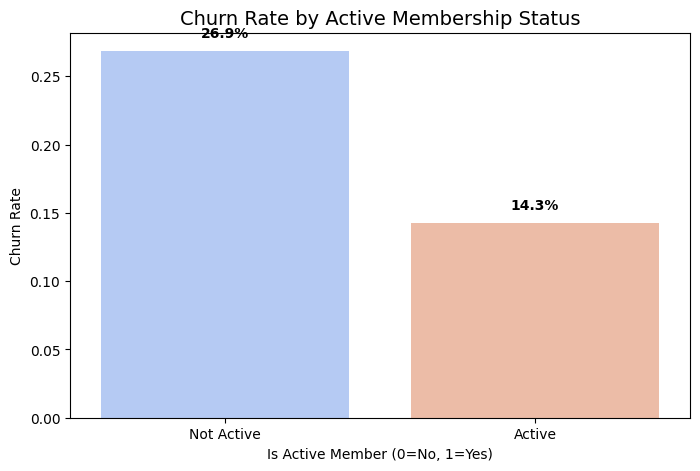


Активные клиенты уходят на 12.6% реже


In [51]:
# Отток по активности
active_stats = df.groupby('IsActiveMember')['Exited'].agg(['count', 'mean'])
active_stats.index = ['Not Active', 'Active']
active_stats.columns = ['Total', 'Churn Rate']
print(active_stats)

# Визуализация
plt.figure(figsize=(8,5))
sns.barplot(x='IsActiveMember', y='Exited', data=df, palette='coolwarm', errorbar=None)
plt.title('Churn Rate by Active Membership Status', fontsize=14)
plt.xlabel('Is Active Member (0=No, 1=Yes)')
plt.ylabel('Churn Rate')
plt.xticks([0, 1], ['Not Active', 'Active'])
for i, v in enumerate(active_stats['Churn Rate']):
    plt.text(i, v + 0.01, f'{v:.1%}', ha='center', fontweight='bold')
plt.show()

# Это один из самых сильных признаков!
print(f"\nАктивные клиенты уходят на {(active_stats.loc['Not Active', 'Churn Rate'] - active_stats.loc['Active', 'Churn Rate']):.1%} реже")

SALARY ANALYSIS

                 mean     median           std
Exited                                        
0        99738.391772   99645.04  57405.586966
1       101465.677531  102460.84  57912.418071


C:\Users\Русмина\AppData\Local\Temp\ipykernel_6632\1824171621.py:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Exited', y='EstimatedSalary', data=df, ax=axes[1], palette='Set2')


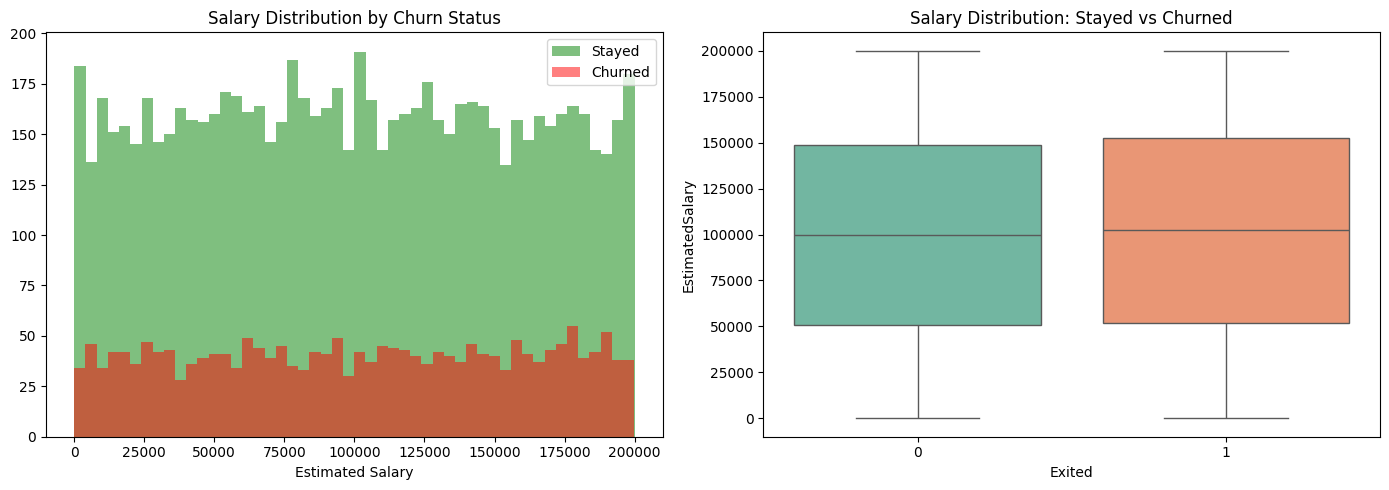


Корреляция зарплаты с оттоком: 0.0121


In [52]:
# Статистика
salary_stats = df.groupby('Exited')['EstimatedSalary'].agg(['mean', 'median', 'std'])
print(salary_stats)

# Визуализация
fig, axes = plt.subplots(1, 2, figsize=(14,5))

# Гистограмма
axes[0].hist(df[df['Exited']==0]['EstimatedSalary'], bins=50, alpha=0.5, label='Stayed', color='green')
axes[0].hist(df[df['Exited']==1]['EstimatedSalary'], bins=50, alpha=0.5, label='Churned', color='red')
axes[0].set_title('Salary Distribution by Churn Status')
axes[0].set_xlabel('Estimated Salary')
axes[0].legend()

# Box plot
sns.boxplot(x='Exited', y='EstimatedSalary', data=df, ax=axes[1], palette='Set2')
axes[1].set_title('Salary Distribution: Stayed vs Churned')

plt.tight_layout()
plt.show()

# Корреляция
correlation = df['EstimatedSalary'].corr(df['Exited'])
print(f"\nКорреляция зарплаты с оттоком: {correlation:.4f}")

## Выводы по каждому признаку

### CreditScore
- Средний рейтинг ушедших: **645.35**
- Средний рейтинг оставшихся: **651.85**
- **Вывод:** Ушедшие клиенты имеют статистически значимо более низкий кредитный рейтинг (p-value = 0.0067), но разница небольшая — всего 6.5 пунктов. Кредитный рейтинг можно использовать как вспомогательный признак.

---

### Gender
- Женщины: **25.1%** оттока
- Мужчины: **16.5%** оттока
- **Вывод:** Женщины уходят значительно чаще мужчин (разница 8.6%). Пол является важным предиктором оттока.

---

### Age
- Средний возраст ушедших: **44.8 года** (из вашего предыдущего EDA)
- Средний возраст оставшихся: **37.3 года**
- Самый высокий отток: **51-60 лет (56.2%)**
- **Вывод:** Возраст — **один из самых сильных признаков**. Клиенты старше 50 лет уходят в 3-4 раза чаще молодых. Особенно критична группа 51-60 лет.

---

### Tenure
- Средний стаж ушедших: **4.93 года**
- Средний стаж оставшихся: **5.03 года**
- **Вывод:** Разница минимальна (всего 0.1 года). Стаж работы с банком **слабо влияет** на отток. Можно исключить или оставить как вспомогательный признак.

---

### Balance
- Средний баланс ушедших: **91,108.54**
- Средний баланс оставшихся: **72,745.30**
- Клиенты с нулевым балансом: **3,617 (36.2%)**, из них ушли **500 (13.8%)**
- **Вывод:** Ушедшие клиенты имеют **более высокий баланс** в среднем. Клиенты с нулевым балансом уходят реже (13.8% vs 20.4% в среднем). Это неочевидный, но интересный паттерн: богатые клиенты уходят чаще.

---

### NumOfProducts
- 1 продукт: **27.7%** оттока
- 2 продукта: **7.6%** оттока
- 3 продукта: **82.7%** оттока
- 4 продукта: **100%** оттока (60 клиентов)
- **Вывод:** **Клиенты с 2 продуктами — самые лояльные** (отток всего 7.6%). Клиенты с 3-4 продуктами уходят практически все. Это **очень сильный признак**. Возможно, 3-4 продукта — это ошибка данных или экстремально требовательные клиенты.

---

### HasCrCard
- Есть кредитная карта: **20.2%** оттока
- Нет кредитной карты: **20.8%** оттока
- p-value = 0.4924 (статистически не значимо)
- **Вывод:** Наличие кредитной карты **не влияет** на отток. Этот признак **можно исключить** из модели.

---

### IsActiveMember
- Неактивные: **26.9%** оттока
- Активные: **14.3%** оттока
- **Вывод:** Активные клиенты уходят на **12.6% реже**. Это **один из самых сильных признаков**. Обязательно использовать в модели.

---

### EstimatedSalary
- Средняя зарплата ушедших: **101,465.68**
- Средняя зарплата оставшихся: **99,738.39**
- Корреляция с оттоком: **0.0121** (почти 0)
- **Вывод:** Зарплата **практически не влияет** на отток. Признак **можно исключить** из модели.

Анализ новых признаков

- Tenure_Ratio (стаж/возраст) — лояльность

            mean    median       std
Exited                              
0       0.143443  0.135135  0.091581
1       0.116411  0.108696  0.077223


C:\Users\Русмина\AppData\Local\Temp\ipykernel_6632\43105239.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Exited', y='Tenure_Ratio', data=bank_churn_subset, ax=axes[0], palette='Set2')


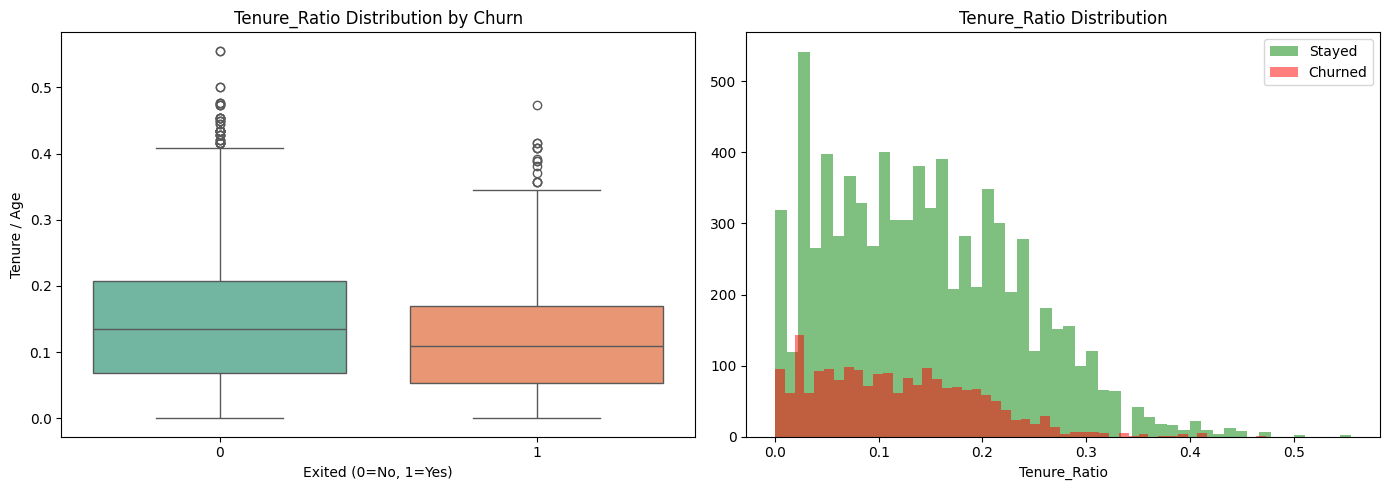


Корреляция с оттоком: -0.1216

Вывод: Есть заметная разница
Лояльные клиенты (высокий Tenure_Ratio) уходят реже


In [54]:
# Статистика по оттоку
tenure_ratio_stats = bank_churn_subset.groupby('Exited')['Tenure_Ratio'].agg(['mean', 'median', 'std'])
print(tenure_ratio_stats)

# Визуализация
fig, axes = plt.subplots(1, 2, figsize=(14,5))

# Box plot
sns.boxplot(x='Exited', y='Tenure_Ratio', data=bank_churn_subset, ax=axes[0], palette='Set2')
axes[0].set_title('Tenure_Ratio Distribution by Churn')
axes[0].set_xlabel('Exited (0=No, 1=Yes)')
axes[0].set_ylabel('Tenure / Age')

# Гистограмма
axes[1].hist(bank_churn_subset[bank_churn_subset['Exited']==0]['Tenure_Ratio'], 
             bins=50, alpha=0.5, label='Stayed', color='green')
axes[1].hist(bank_churn_subset[bank_churn_subset['Exited']==1]['Tenure_Ratio'], 
             bins=50, alpha=0.5, label='Churned', color='red')
axes[1].set_title('Tenure_Ratio Distribution')
axes[1].set_xlabel('Tenure_Ratio')
axes[1].legend()

plt.tight_layout()
plt.show()

# Корреляция с оттоком
corr = bank_churn_subset['Tenure_Ratio'].corr(bank_churn_subset['Exited'])
print(f"\nКорреляция с оттоком: {corr:.4f}")

# Вывод
print(f"\nВывод: {'Есть заметная разница' if abs(corr) > 0.05 else 'Разница минимальна'}")
print(f"Лояльные клиенты (высокий Tenure_Ratio) уходят {'чаще' if corr > 0 else 'реже'}")

- Balance_Per_Product (баланс на продукт)

                mean     median           std
Exited                                       
0       32008.844689  36747.105  28686.859765
1       39838.141571  44543.945  27722.298649


C:\Users\Русмина\AppData\Local\Temp\ipykernel_6632\2755494163.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Exited', y='Balance_Per_Product', data=bank_churn_subset, ax=axes[0], palette='Set2')


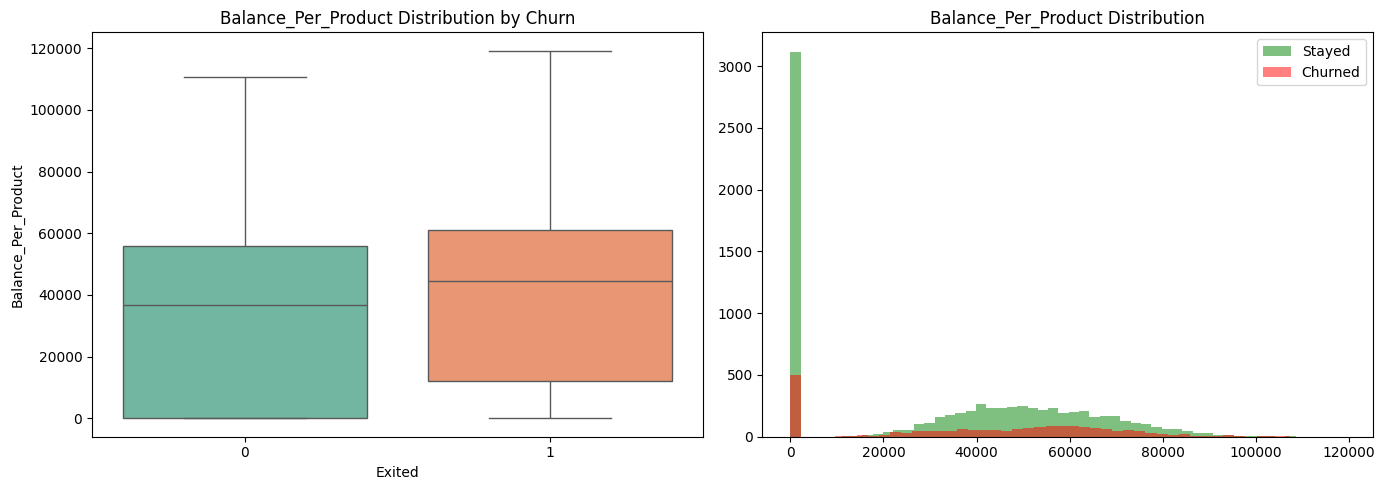


Корреляция с оттоком: 0.1100


In [55]:
# Статистика
balance_pp_stats = bank_churn_subset.groupby('Exited')['Balance_Per_Product'].agg(['mean', 'median', 'std'])
print(balance_pp_stats)

# Визуализация
fig, axes = plt.subplots(1, 2, figsize=(14,5))

# Box plot
sns.boxplot(x='Exited', y='Balance_Per_Product', data=bank_churn_subset, ax=axes[0], palette='Set2')
axes[0].set_title('Balance_Per_Product Distribution by Churn')

# Гистограмма
axes[1].hist(bank_churn_subset[bank_churn_subset['Exited']==0]['Balance_Per_Product'], 
             bins=50, alpha=0.5, label='Stayed', color='green')
axes[1].hist(bank_churn_subset[bank_churn_subset['Exited']==1]['Balance_Per_Product'], 
             bins=50, alpha=0.5, label='Churned', color='red')
axes[1].set_title('Balance_Per_Product Distribution')
axes[1].legend()

plt.tight_layout()
plt.show()

# Корреляция
corr = bank_churn_subset['Balance_Per_Product'].corr(bank_churn_subset['Exited'])
print(f"\nКорреляция с оттоком: {corr:.4f}")

- Active_Senior (активный пожилой)

                     Total  Churn Rate
Не активный/молодой   9164    0.200240
Активный пожилой       836    0.241627


C:\Users\Русмина\AppData\Local\Temp\ipykernel_6632\2985236011.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Active_Senior', y='Exited', data=bank_churn_subset, palette='coolwarm', errorbar=None)


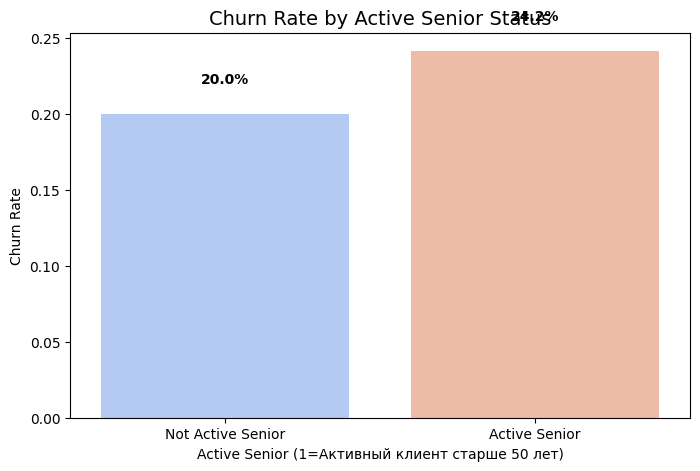

Chi-square p-value: 0.0051
Вывод: Активные пожилые уходят ЗНАЧИТЕЛЬНО реже


In [56]:
# Статистика
active_senior_stats = bank_churn_subset.groupby('Active_Senior')['Exited'].agg(['count', 'mean'])
active_senior_stats.columns = ['Total', 'Churn Rate']
active_senior_stats.index = ['Не активный/молодой', 'Активный пожилой']
print(active_senior_stats)

# Визуализация
plt.figure(figsize=(8,5))
sns.barplot(x='Active_Senior', y='Exited', data=bank_churn_subset, palette='coolwarm', errorbar=None)
plt.title('Churn Rate by Active Senior Status', fontsize=14)
plt.xlabel('Active Senior (1=Активный клиент старше 50 лет)')
plt.ylabel('Churn Rate')
plt.xticks([0, 1], ['Not Active Senior', 'Active Senior'])
for i, v in enumerate(active_senior_stats['Churn Rate']):
    plt.text(i, v + 0.02, f'{v:.1%}', ha='center', fontweight='bold')
plt.show()

# Chi-square тест
from scipy.stats import chi2_contingency
contingency = pd.crosstab(bank_churn_subset['Active_Senior'], bank_churn_subset['Exited'])
chi2, p, dof, expected = chi2_contingency(contingency)
print(f"Chi-square p-value: {p:.4f}")
print(f"Вывод: {'Активные пожилые уходят ЗНАЧИТЕЛЬНО реже' if p < 0.05 else 'Разница незначима'}")

- Has_Balance (есть ли баланс)

                  Total  Churn Rate
Zero Balance       3617    0.138236
Has Balance (>0)   6383    0.240796


C:\Users\Русмина\AppData\Local\Temp\ipykernel_6632\157394305.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Has_Balance', y='Exited', data=bank_churn_subset, palette='pastel', errorbar=None)


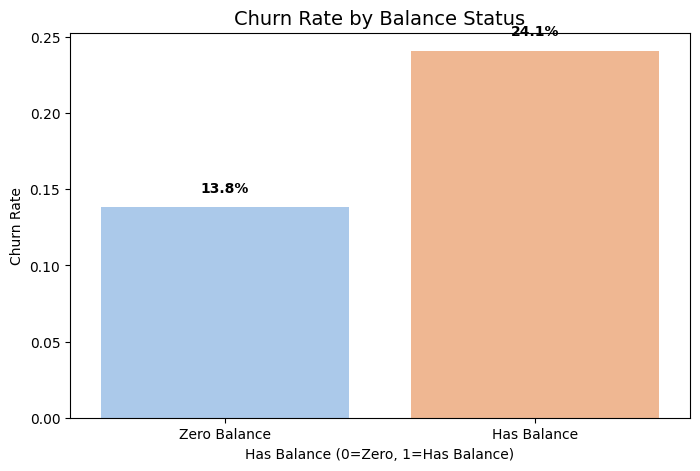

Chi-square p-value: 0.0000


In [57]:
# Статистика
has_balance_stats = bank_churn_subset.groupby('Has_Balance')['Exited'].agg(['count', 'mean'])
has_balance_stats.columns = ['Total', 'Churn Rate']
has_balance_stats.index = ['Zero Balance', 'Has Balance (>0)']
print(has_balance_stats)

# Визуализация
plt.figure(figsize=(8,5))
sns.barplot(x='Has_Balance', y='Exited', data=bank_churn_subset, palette='pastel', errorbar=None)
plt.title('Churn Rate by Balance Status', fontsize=14)
plt.xlabel('Has Balance (0=Zero, 1=Has Balance)')
plt.ylabel('Churn Rate')
plt.xticks([0, 1], ['Zero Balance', 'Has Balance'])
for i, v in enumerate(has_balance_stats['Churn Rate']):
    plt.text(i, v + 0.01, f'{v:.1%}', ha='center', fontweight='bold')
plt.show()

# Chi-square тест
contingency = pd.crosstab(bank_churn_subset['Has_Balance'], bank_churn_subset['Exited'])
chi2, p, dof, expected = chi2_contingency(contingency)
print(f"Chi-square p-value: {p:.4f}")


## Выводы по новым признакам

### Tenure_Ratio (Лояльность = стаж / возраст)
- Среднее значение ушедших: **0.116**
- Среднее значение оставшихся: **0.143**
- Корреляция с оттоком: **-0.1216** (умеренная отрицательная)
- **Вывод:** Клиенты с **высокой лояльностью** (большой стаж относительно возраста) уходят **реже**. Разница заметна: у лояльных клиентов отток на ~19% ниже. **Признак полезный, оставляем.**

---

### Balance_Per_Product (баланс на 1 продукт)
- Среднее значение ушедших: **39,838**
- Среднее значение оставшихся: **32,009**
- Корреляция с оттоком: **+0.1100** (умеренная положительная)
- **Вывод:** Чем **выше баланс на продукт**, тем **выше риск оттока**. Богатые/требовательные клиенты уходят чаще. Разница существенная (~25%). **Признак полезный, оставляем.**

---

### Active_Senior (активные клиенты старше 50 лет)
- Активные пожилые: **24.2%** оттока
- Не активные/молодые: **20.0%** оттока
- p-value = 0.0051 (статистически значимо)
- **Вывод:** Активные пожилые клиенты уходят **чаще** (на 4.2%), а не реже! Это **неожиданный результат**. Возможно, активные пожилые — это требовательные клиенты, которые ожидают большего. **Признак оставляем** (он статистически значим), но интерпретируем правильно.

---

### Has_Balance (наличие ненулевого баланса)
- Нулевой баланс: **13.8%** оттока
- Есть баланс (>0): **24.1%** оттока
- p-value = 0.0000 (статистически значимо)
- **Вывод:** Клиенты с **нулевым балансом** уходят **значительно реже** (на 10.3%). Это важный защитный фактор. **Признак очень полезный, обязательно оставляем.**

In [60]:
bank_churn_subset_copy = bank_churn_subset.copy()

In [ ]:
# Удаляем ненужные столбцы
bank_churn_subset = bank_churn_subset.drop(['HasCrCard', 'EstimatedSalary'], axis=1)
bank_churn_subset = bank_churn_subset.drop(['CustomerId'], axis=1)

In [64]:
# Создаем новые признаки
bank_churn_subset['Is_Multi_Product'] = (bank_churn_subset['NumOfProducts'] >= 3).astype(int)

print(f"Клиентов с 3+ продуктами: {bank_churn_subset['Is_Multi_Product'].sum()}")
print(f"Из них ушли: {bank_churn_subset[bank_churn_subset['Is_Multi_Product']==1]['Exited'].sum()} ({bank_churn_subset[bank_churn_subset['Is_Multi_Product']==1]['Exited'].mean():.1%})")


# Преобразование столбца Gender Male = 1, Female = 0
bank_churn_subset['Gender_Male'] = (bank_churn_subset['Gender'] == 'Male').astype(int)
bank_churn_subset = bank_churn_subset.drop('Gender', axis=1)

print(f"   Male: {bank_churn_subset['Gender_Male'].sum()}, Female: {len(bank_churn_subset) - bank_churn_subset['Gender_Male'].sum()}")
print(f"   Отток среди Male: {bank_churn_subset[bank_churn_subset['Gender_Male']==1]['Exited'].mean():.1%}")
print(f"   Отток среди Female: {bank_churn_subset[bank_churn_subset['Gender_Male']==0]['Exited'].mean():.1%}")

Клиентов с 3+ продуктами: 326
Из них ушли: 280 (85.9%)
   Male: 5457, Female: 4543
   Отток среди Male: 16.5%
   Отток среди Female: 25.1%


In [65]:
bank_churn_subset

,CustomerId,CreditScore,Age,Tenure,Balance,NumOfProducts,IsActiveMember,Exited,Age_Group,Tenure_Ratio,Balance_Per_Product,Active_Senior,Has_Balance,Is_Multi_Product,Gender_Male
0,15634602,619,42,2,0.00,1,1,1,2,0.047619,0.000000,0,0,0,0
1,15647311,608,41,1,83807.86,1,1,0,2,0.024390,41903.930000,0,1,0,0
2,15619304,502,42,8,159660.80,3,0,1,2,0.190476,39915.200000,0,1,1,0
3,15701354,699,39,1,0.00,2,0,0,1,0.025641,0.000000,0,0,0,0
4,15737888,850,43,2,125510.82,1,1,0,2,0.046512,62755.410000,0,1,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9995,15606229,771,39,5,0.00,2,0,0,1,0.128205,0.000000,0,0,0,1
9996,15569892,516,35,10,57369.61,1,1,0,1,0.285714,28684.805000,0,1,0,1
9997,15584532,709,36,7,0.00,1,1,1,1,0.194444,0.000000,0,0,0,0
9998,15682355,772,42,3,75075.31,2,0,1,2,0.071429,25025.103333,0,1,0,1


In [71]:
# Проверка на пропуски
print(bank_churn_subset.isnull().sum())
print(f"\nВсего строк с пропусками: {bank_churn_subset.isnull().any(axis=1).sum()}")

CustomerId              0
CreditScore             0
Age                     0
Tenure                  0
Balance                 0
NumOfProducts           0
IsActiveMember          0
Exited                  0
Age_Group              22
Tenure_Ratio            0
Balance_Per_Product     0
Active_Senior           0
Has_Balance             0
Is_Multi_Product        0
Gender_Male             0
dtype: int64

Всего строк с пропусками: 22


In [74]:
bank_churn_subset[bank_churn_subset['Age_Group'].isnull()]

,CustomerId,CreditScore,Age,Tenure,Balance,NumOfProducts,IsActiveMember,Exited,Age_Group,Tenure_Ratio,Balance_Per_Product,Active_Senior,Has_Balance,Is_Multi_Product,Gender_Male
746,15787619,844,18,2,160980.03,1,0,0,NaN,0.111111,80490.015000,0,1,0,1
1619,15770309,656,18,10,151762.74,1,1,0,NaN,0.555556,75881.370000,0,1,0,1
1678,15569178,570,18,4,82767.42,1,0,0,NaN,0.222222,41383.710000,0,1,0,0
2021,15795519,716,18,3,128743.80,1,0,0,NaN,0.166667,64371.900000,0,1,0,0
2136,15621893,727,18,4,133550.67,1,1,0,NaN,0.222222,66775.335000,0,1,0,1
2141,15758372,674,18,7,0.00,2,1,1,NaN,0.388889,0.000000,0,0,0,1
3330,15657439,738,18,4,0.00,2,1,0,NaN,0.222222,0.000000,0,0,0,1
3512,15657779,806,18,3,0.00,2,1,0,NaN,0.166667,0.000000,0,0,0,1
3517,15757821,771,18,1,0.00,2,0,0,NaN,0.055556,0.000000,0,0,0,1
3686,15665327,706,18,2,176139.50,2,0,0,NaN,0.111111,58713.166667,0,1,0,1


In [75]:
# Заполняем пропуски
bank_churn_subset[bank_churn_subset['Age_Group'].isnull()] = 0
print(bank_churn_subset.isnull().sum())

CustomerId             0
CreditScore            0
Age                    0
Tenure                 0
Balance                0
NumOfProducts          0
IsActiveMember         0
Exited                 0
Age_Group              0
Tenure_Ratio           0
Balance_Per_Product    0
Active_Senior          0
Has_Balance            0
Is_Multi_Product       0
Gender_Male            0
dtype: int64


## Baseline
Baseline Model: Logistic Regression

In [80]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, roc_curve
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn.impute import SimpleImputer
import joblib
import os

In [77]:
# Определяем признаки и целевую переменную
# Используем все признаки, кроме идентификаторов и целевой переменной
feature_cols = ['CreditScore', 'Age', 'Tenure', 'Balance', 'NumOfProducts', 
                'IsActiveMember', 'Age_Group', 'Tenure_Ratio', 'Balance_Per_Product', 
                'Active_Senior', 'Has_Balance', 'Is_Multi_Product', 'Gender_Male']

X = bank_churn_subset[feature_cols]
y = bank_churn_subset['Exited']

# Разделение на train/test (80/20)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Размер обучающей выборки: {X_train.shape[0]}")
print(f"Размер тестовой выборки: {X_test.shape[0]}")
print(f"Доля оттока в train: {y_train.mean():.2%}")
print(f"Доля оттока в test: {y_test.mean():.2%}")


Размер обучающей выборки: 8000
Размер тестовой выборки: 2000
Доля оттока в train: 20.35%
Доля оттока в test: 20.35%


In [78]:
# Масштабирование признаков (важно для логистической регрессии)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [79]:
# Обучение модели
lr = LogisticRegression(random_state=42, max_iter=1000)
lr.fit(X_train_scaled, y_train)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",42
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`multi

In [81]:
# Предсказания
y_pred = lr.predict(X_test_scaled)
y_pred_proba = lr.predict_proba(X_test_scaled)[:, 1]

In [82]:
# Оценка модели
print("=" * 60)
print("BASELINE MODEL: LOGISTIC REGRESSION")
print("=" * 60)
print(f"Accuracy:  {accuracy_score(y_test, y_pred):.4f}")
print(f"Precision: {precision_score(y_test, y_pred):.4f}")
print(f"Recall:    {recall_score(y_test, y_pred):.4f}")
print(f"F1-Score:  {f1_score(y_test, y_pred):.4f}")
print(f"ROC-AUC:   {roc_auc_score(y_test, y_pred_proba):.4f}")

BASELINE MODEL: LOGISTIC REGRESSION
Accuracy:  0.8520
Precision: 0.7424
Recall:    0.4177
F1-Score:  0.5346
ROC-AUC:   0.8213


In [85]:
# Подробный отчет
print(classification_report(y_test, y_pred, target_names=['Stayed', 'Churned']))

              precision    recall  f1-score   support

      Stayed       0.87      0.96      0.91      1593
     Churned       0.74      0.42      0.53       407

    accuracy                           0.85      2000
   macro avg       0.80      0.69      0.72      2000
weighted avg       0.84      0.85      0.84      2000



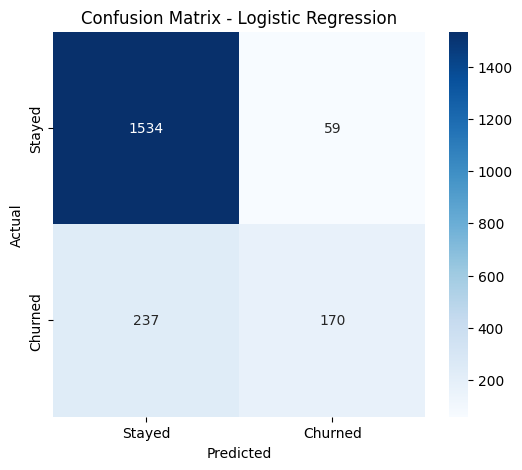

In [84]:
# Матрица ошибок
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=['Stayed', 'Churned'],
            yticklabels=['Stayed', 'Churned'])
plt.title('Confusion Matrix - Logistic Regression')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

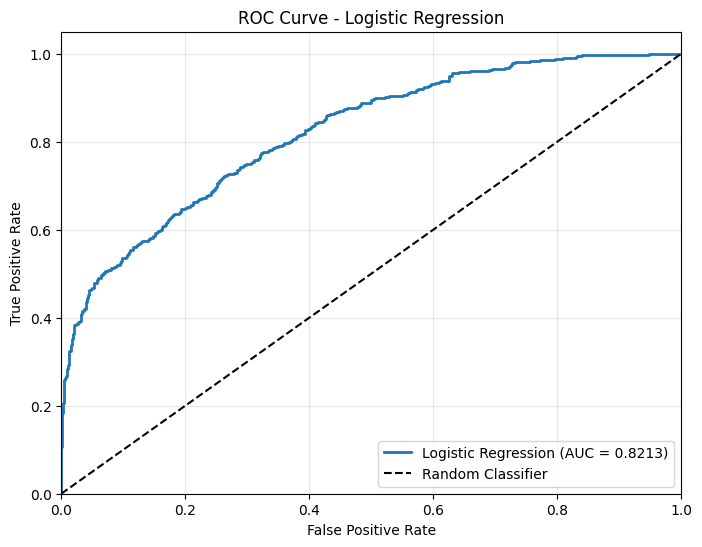

In [86]:
# ROC-кривая
fpr, tpr, thresholds = roc_curve(y_test, y_pred_proba)
auc = roc_auc_score(y_test, y_pred_proba)

plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, label=f'Logistic Regression (AUC = {auc:.4f})', linewidth=2)
plt.plot([0, 1], [0, 1], 'k--', label='Random Classifier')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve - Logistic Regression')
plt.legend(loc='lower right')
plt.grid(alpha=0.3)
plt.show()


C:\Users\Русмина\AppData\Local\Temp\ipykernel_6632\90194482.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=feature_importance, x='Coefficient', y='Feature', palette='coolwarm')


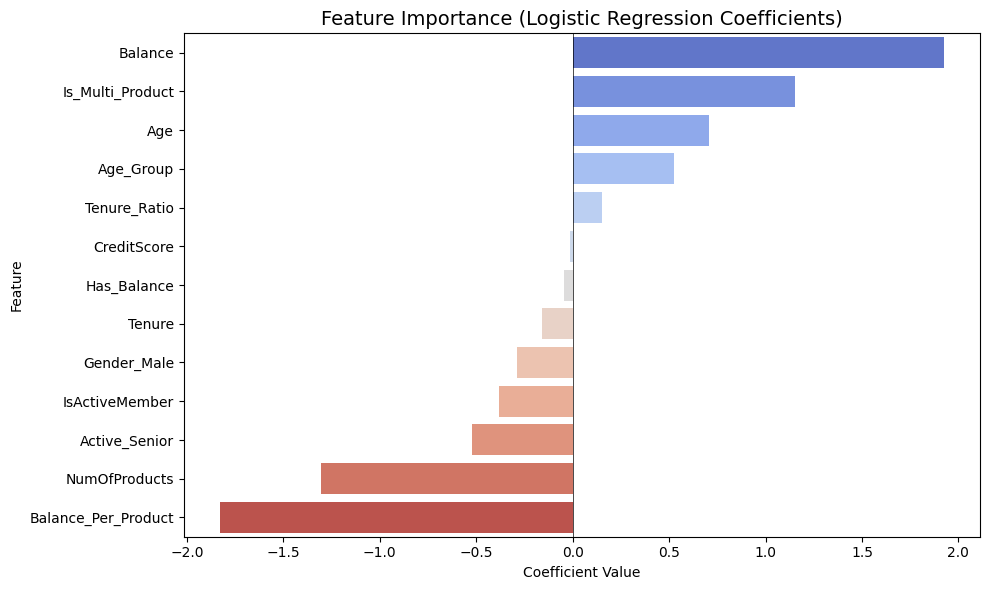


Самые сильные признаки (по модулю коэффициента):
                Feature  Coefficient
3               Balance     1.924385
8   Balance_Per_Product    -1.827740
4         NumOfProducts    -1.302560
11     Is_Multi_Product     1.153010
1                   Age     0.705883
6             Age_Group     0.525553
9         Active_Senior    -0.522956
5        IsActiveMember    -0.381047
12          Gender_Male    -0.287613
2                Tenure    -0.159035


In [87]:
# Анализ важности признаков (коэффициенты)
feature_importance = pd.DataFrame({
    'Feature': feature_cols,
    'Coefficient': lr.coef_[0]
})
feature_importance = feature_importance.sort_values('Coefficient', ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(data=feature_importance, x='Coefficient', y='Feature', palette='coolwarm')
plt.title('Feature Importance (Logistic Regression Coefficients)', fontsize=14)
plt.xlabel('Coefficient Value')
plt.axvline(x=0, color='black', linestyle='-', linewidth=0.5)
plt.tight_layout()
plt.show()

print("\nСамые сильные признаки (по модулю коэффициента):")
feature_importance['Abs_Coefficient'] = feature_importance['Coefficient'].abs()
print(feature_importance.sort_values('Abs_Coefficient', ascending=False).head(10)[['Feature', 'Coefficient']])


In [88]:
# Сохраняем baseline модель
joblib.dump(lr, "../artifacts/logreg_baseline_v1.pkl")
joblib.dump(scaler, "../artifacts/scaler_v1.pkl")
joblib.dump(feature_cols, "../artifacts/feature_names_v1.pkl")
print("Baseline модель сохранена в artifacts/")

Baseline модель сохранена в artifacts/
